# Encoding the hierarchical building: a two-tier VSA cascade (and a fully-combined Tier 3 for comparison)

Ground truth was built and visualized in `hierarchical_building.ipynb`
(`BuildingEnv`: rooms containing furniture, with genuinely nested labels --
a point on furniture is simultaneously "in this room" and "on this
furniture"). This notebook encodes it with `MultiScaleFHRRMap`-style
models, three ways:

- **Tier 1 (coarse, one shared memory):** classify room identity
  (`living_room`/`bedroom`/`kitchen`/`bathroom`/`wall`) for any point in the
  building. All 5 categories share one memory and one learned multi-scale
  mixture over length scales `[0.5, 0.2, 0.05]` (re-tuned for room/wall
  sizes here, vs. the original room dataset's `[0.4, 0.15, 0.05]`).
- **Tier 2 (fine, one memory per room):** classify what a point is on --
  `floor` (the open space) or one of that room's furniture items -- as an
  explicit 3-way classification. Each room gets its own clean memory
  (removing room-vs-room crosstalk), but *within* a room, `floor` and its
  2 furniture items share one memory and mixture, over length scales
  `[0.3, 0.15, 0.05]` (re-tuned for furniture sizes, ~0.15-0.5 units). We
  first tried inferring floor from low confidence with no explicit floor
  class, and found it fails badly (a floor query in the bathroom came back
  "tub" at 94% confidence) -- with no floor class to compete against,
  furniture had nothing to lose by claiming the whole room. An explicit
  floor class also reproduces the original room dataset's big-class
  -vs-small-classes setup (floor is ~70-80% of each room), which is what
  gave the multi-scale mixture real competitive pressure to resolve there.
- **Tier 3 (everything, one house-wide memory):** the fully-combined
  design we originally set aside -- one shared memory for the whole house,
  room identity and floor/furniture identity both bound in, each at its
  own multi-scale mixture. Built and compared directly against Tiers 1+2
  after understanding them separately, specifically to measure the
  crosstalk cost of combining everything into one vector.

Querying a position via the two-tier cascade: Tier 1 says which room, then
that room's Tier 2 model says floor or which furniture. Tier 3 answers both
questions from the same single memory.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from multiscalessps.envs.building import make_default_building
from multiscalessps.metrics import kl_divergence

DIM = 1024
SEED = 0
device = "mps"

building = make_default_building()
H, W = building.grid_size
(xmin, xmax), (ymin, ymax) = building.bounds
extent = (xmin, xmax, ymin, ymax)
eps = 1e-12

positions = building.dense_positions()
xy_all = np.array([p for p, _ in positions], dtype=np.float32)
room_labels_all = np.array([lbl["room"] for _, lbl in positions])
furniture_labels_all = np.array([lbl["furniture"] for _, lbl in positions], dtype=object)

print(f"grid: {building.grid_size}, total cells: {len(xy_all)}")
print(f"rooms: {building.room_names}")
print(f"furniture: {building.furniture_names}")

grid: (128, 128), total cells: 16384
rooms: ['living_room', 'bedroom', 'kitchen', 'bathroom']
furniture: ['sofa', 'tv_stand', 'bed', 'wardrobe', 'table', 'stove', 'sink', 'tub']


## Model and shared helpers

`MultiScaleFHRRMap` is copied verbatim from `multi_scale_learning.ipynb`
(shared memory, class binding, learned multi-scale mixture, temperature
-calibrated `predict_proba`) -- both tiers use it, since Tier 1 needs a
shared memory across rooms and Tier 2 needs a shared memory across a room's
furniture items. The only thing that differs between instances is the
class vocabulary, the length scales, and which points it's trained on.

`make_split`, `train_model`, and `calibrate_temperature` generalize the
per-notebook patterns from `baseline_comparison.ipynb` so the same code
trains and calibrates every one of the 5 models below (1 Tier-1 + 4 Tier-2)
identically.

In [2]:
class MultiScaleFHRRMap(nn.Module):
    """Shared global memory, multi-scale mixture over discrete length scales.
    Copied verbatim from multi_scale_learning.ipynb."""

    def __init__(self, dim, spatial_dim, num_classes, lengthscales, device="cpu"):
        super().__init__()
        self.dim = dim
        self.spatial_dim = spatial_dim
        self.num_classes = num_classes
        self.lengthscales = torch.tensor(lengthscales, device=device).float()
        self.num_scales = len(lengthscales)

        axis_phase = 2 * torch.pi * torch.rand(self.num_scales, spatial_dim, dim, device=device) - torch.pi
        class_phase = 2 * torch.pi * torch.rand(num_classes, dim, device=device) - torch.pi
        scale_phase = 2 * torch.pi * torch.rand(self.num_scales, dim, device=device) - torch.pi

        self.register_buffer("axis_phase", axis_phase)
        self.register_buffer("class_vecs", torch.exp(1j * class_phase))
        self.register_buffer("scale_vecs", torch.exp(1j * scale_phase))

        self.scale_logits = nn.Parameter(torch.zeros(self.num_scales, device=device))

    def encode_position(self, x):
        scaled_phase = self.axis_phase / self.lengthscales[:, None, None]
        phase = torch.einsum("nj,kjd->nkd", x, scaled_phase)
        return torch.exp(1j * phase)

    def build_memory(self, points, labels, point_weights=None):
        dev = self.axis_phase.device
        pos = self.encode_position(points.to(dev))
        class_vec = self.class_vecs[labels.to(dev)]
        scale_vec = self.scale_vecs
        atoms = pos * class_vec[:, None, :] * scale_vec[None, :, :]
        scale_weights = F.softmax(self.scale_logits, dim=0)
        atoms = atoms * scale_weights[None, :, None]
        if point_weights is not None:
            atoms = atoms * point_weights.to(dev)[:, None, None]
        records = atoms.sum(dim=1)
        memory = records.sum(dim=0)
        return memory / torch.linalg.norm(memory)

    def score_classes(self, memory, query_points):
        pos = self.encode_position(query_points.to(self.axis_phase.device))
        probes = pos[:, :, None, :] * self.scale_vecs[None, :, None, :] * self.class_vecs[None, None, :, :]
        sims = torch.real(
            torch.sum(torch.conj(probes) * memory[None, None, None, :], dim=-1)
        ) / self.dim
        return sims.sum(dim=1)

    def predict_proba(self, memory, query_points, temperature=1.0):
        scores = self.score_classes(memory, query_points) / temperature
        scores = scores - scores.max(dim=-1, keepdim=True).values
        return F.softmax(scores, dim=-1)


def make_split(labels_idx, num_classes, val_frac=0.2, seed=SEED):
    """Stratified train/val split of indices into ``labels_idx``."""
    rng = np.random.default_rng(seed)
    train_idx, val_idx = [], []
    for c in range(num_classes):
        cp = np.flatnonzero(labels_idx == c)
        rng.shuffle(cp)
        n_val = max(1, int(round(val_frac * len(cp))))
        val_idx.append(cp[:n_val])
        train_idx.append(cp[n_val:])
    return np.concatenate(train_idx), np.concatenate(val_idx)


def train_model(model, train_points, train_labels, class_weights, n_epochs=200, lr=0.05, log_mixture=False):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    mixture_history = [] if log_mixture else None
    for epoch in range(n_epochs):
        optimizer.zero_grad()
        memory = model.build_memory(train_points, train_labels)
        scores = model.score_classes(memory, train_points)
        loss = F.cross_entropy(scores, train_labels, weight=class_weights)
        loss.backward()
        optimizer.step()
        if log_mixture:
            mixture_history.append(F.softmax(model.scale_logits, dim=0).detach().cpu().numpy().copy())
    with torch.no_grad():
        memory = model.build_memory(train_points, train_labels)
    return memory, (np.array(mixture_history) if log_mixture else None)


def calibrate_temperature(model, memory, val_points_t, val_labels_idx, class_weights_np, temperatures=None):
    if temperatures is None:
        temperatures = np.logspace(-4, 1, 60)
    val_nll = []
    for t in temperatures:
        with torch.no_grad():
            probs = model.predict_proba(memory, val_points_t, temperature=t).cpu().numpy()
        logp = np.log(probs[np.arange(len(val_labels_idx)), val_labels_idx] + 1e-12)
        w = class_weights_np[val_labels_idx]
        val_nll.append(-(w * logp).sum() / w.sum())
    return temperatures[int(np.argmin(val_nll))]


def build_memory_with_scale_logits(model, points, labels, scale_logits):
    """Build a memory using the given scale_logits instead of the model's current
    ones, leaving the model's own (trained) scale_logits untouched afterward.
    Used to reconstruct the "before training" memory (scale_logits=0, i.e. a
    uniform scale mixture) from an already-trained model, since scale_logits is
    the only trained parameter -- axis_phase/class_vecs/scale_vecs never change."""
    saved = model.scale_logits.data.clone()
    model.scale_logits.data.copy_(scale_logits.to(model.scale_logits.device))
    with torch.no_grad():
        memory = model.build_memory(points, labels)
    model.scale_logits.data.copy_(saved)
    return memory


def decode_class_maps(model, memory, query_points, class_to_idx, gt_maps, H, W, mask=None, temperature=1.0):
    """Decode per-class probability maps + KL vs. ground truth for a given memory."""
    with torch.no_grad():
        probs = model.predict_proba(memory, query_points, temperature=temperature).cpu().numpy()
    est_maps, kl = {}, {}
    for name, idx in class_to_idx.items():
        if mask is None:
            m = probs[:, idx].reshape(H, W) + eps
        else:
            full = np.zeros(H * W)
            full[mask] = probs[:, idx] + eps
            m = full.reshape(H, W)
        est_maps[name] = m / m.sum()
        kl[name] = kl_divergence(est_maps[name], gt_maps[name])
    return est_maps, kl

In [3]:
class MultiScaleFHRRMapLearnedTemp(MultiScaleFHRRMap):
    """MultiScaleFHRRMap with a learnable temperature folded directly into the
    training loss, mirroring HouseFHRRMapLearnedTemp (Tier 3, below): the raw
    FHRR correlation scores are O(1/sqrt(dim)) in magnitude, so an untempered
    F.cross_entropy sees a near-uniform softmax regardless of which class is
    correct, and scale_logits gets almost no gradient signal."""

    def __init__(self, *args, init_temp=0.01, **kwargs):
        super().__init__(*args, **kwargs)
        self.log_temperature = nn.Parameter(
            torch.tensor(float(np.log(init_temp)), device=self.axis_phase.device)
        )

    @property
    def temperature(self):
        return torch.exp(self.log_temperature)

    def scaled_scores(self, memory, query_points):
        return self.score_classes(memory, query_points) / self.temperature


def train_model_learned_temp(model, train_points, train_labels, class_weights, n_epochs=200, lr=0.05):
    """Like train_model, but the loss uses model.scaled_scores (temperature folded
    into the loss) instead of raw score_classes. Returns (memory, mixture_history,
    loss_history, temperature_history)."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    mixture_history, loss_history, temp_history = [], [], []
    for epoch in range(n_epochs):
        optimizer.zero_grad()
        memory = model.build_memory(train_points, train_labels)
        scores = model.scaled_scores(memory, train_points)
        loss = F.cross_entropy(scores, train_labels, weight=class_weights)
        loss.backward()
        optimizer.step()
        mixture_history.append(F.softmax(model.scale_logits, dim=0).detach().cpu().numpy().copy())
        loss_history.append(loss.item())
        temp_history.append(model.temperature.item())
    with torch.no_grad():
        memory = model.build_memory(train_points, train_labels)
    return memory, np.array(mixture_history), loss_history, temp_history

## Tier 1: room identity (coarse, one shared memory)

Trained on all 16,384 grid cells, 5-way classification (4 rooms + wall).

In [4]:
TIER1_LENGTHSCALES = [0.4, 0.1, 0.01]

room_names_t1 = sorted(set(room_labels_all))
room_to_idx_t1 = {name: i for i, name in enumerate(room_names_t1)}
room_idx_all = np.array([room_to_idx_t1[r] for r in room_labels_all])

train_idx1, val_idx1 = make_split(room_idx_all, num_classes=len(room_names_t1))

train_points1 = torch.tensor(xy_all[train_idx1], device=device)
train_labels1 = torch.tensor(room_idx_all[train_idx1], device=device)
val_points1 = torch.tensor(xy_all[val_idx1], device=device)
val_labels1_idx = room_idx_all[val_idx1]

class_counts1 = torch.bincount(train_labels1, minlength=len(room_names_t1)).float()
class_weights1 = class_counts1.sum() / (len(room_names_t1) * class_counts1)
class_weights1_np = class_weights1.cpu().numpy()

print(f"Tier 1 classes: {room_names_t1}")
print(f"train points: {len(train_idx1)}, val points: {len(val_idx1)}")

torch.manual_seed(SEED)
model1 = MultiScaleFHRRMap(
    dim=DIM, spatial_dim=2, num_classes=len(room_names_t1), lengthscales=TIER1_LENGTHSCALES, device=device,
)
memory1, mixture_hist1 = train_model(model1, train_points1, train_labels1, class_weights1, log_mixture=True)
temp1 = calibrate_temperature(model1, memory1, val_points1, val_labels1_idx, class_weights1_np)

with torch.no_grad():
    val_probs1 = model1.predict_proba(memory1, val_points1, temperature=temp1).cpu().numpy()
val_pred1 = val_probs1.argmax(axis=1)

print(f"\ncalibrated temperature: {temp1:.4g}")
print("learned mixture weights:", dict(zip(["coarse", "medium", "fine"], mixture_hist1[-1].round(3))))
print("\nper-room val recall:")
for name, idx in room_to_idx_t1.items():
    mask = val_labels1_idx == idx
    print(f"  {name:>12s}: {(val_pred1[mask] == idx).mean():.3f}")

Tier 1 classes: [np.str_('bathroom'), np.str_('bedroom'), np.str_('kitchen'), np.str_('living_room'), np.str_('wall')]
train points: 13106, val points: 3278



calibrated temperature: 0.00104
learned mixture weights: {'coarse': np.float32(0.307), 'medium': np.float32(0.404), 'fine': np.float32(0.289)}

per-room val recall:
      bathroom: 0.978
       bedroom: 0.927
       kitchen: 0.911
   living_room: 0.976
          wall: 0.263


### Does the learned-temperature fix change Tier 1's mixture?

Tier 1's `scale_logits` mixture barely moved from uniform under plain
`train_model` (see the takeaway at the end of the notebook). `HouseFHRRMapLearnedTemp`
(Tier 3, below) shows that an untempered `F.cross_entropy` on raw FHRR
scores gives the mixture almost no gradient at all. Retrain Tier 1 with
`MultiScaleFHRRMapLearnedTemp` to check whether "nothing forcing a
resolution" is a real finding about this dataset, or whether it was this
same temperature confound.

In [5]:
torch.manual_seed(SEED)
model1_lt = MultiScaleFHRRMapLearnedTemp(
    dim=DIM, spatial_dim=2, num_classes=len(room_names_t1), lengthscales=TIER1_LENGTHSCALES, device=device,
)
memory1_lt, mixture_hist1_lt, loss_hist1_lt, temp_hist1_lt = train_model_learned_temp(
    model1_lt, train_points1, train_labels1, class_weights1
)

with torch.no_grad():
    val_probs1_lt = model1_lt.predict_proba(
        memory1_lt, val_points1, temperature=model1_lt.temperature.item()
    ).cpu().numpy()
val_pred1_lt = val_probs1_lt.argmax(axis=1)

print(f"Tier 1 learned temperature: {model1_lt.temperature.item():.4g}  (post-hoc calibrated: {temp1:.4g})")
print(f"loss: epoch0={loss_hist1_lt[0]:.4f}  epoch199={loss_hist1_lt[-1]:.4f}")
print("mixture (tempered):  ", dict(zip(["coarse", "medium", "fine"], mixture_hist1_lt[-1].round(3))))
print("mixture (untempered):", dict(zip(["coarse", "medium", "fine"], mixture_hist1[-1].round(3))))
print("\nper-room val recall (tempered):")
for name, idx in room_to_idx_t1.items():
    mask = val_labels1_idx == idx
    print(f"  {name:>12s}: {(val_pred1_lt[mask] == idx).mean():.3f}")

Tier 1 learned temperature: 0.0008634  (post-hoc calibrated: 0.00104)
loss: epoch0=1.2695  epoch199=0.4497
mixture (tempered):   {'coarse': np.float32(0.094), 'medium': np.float32(0.386), 'fine': np.float32(0.52)}
mixture (untempered): {'coarse': np.float32(0.307), 'medium': np.float32(0.404), 'fine': np.float32(0.289)}

per-room val recall (tempered):
      bathroom: 0.975
       bedroom: 0.906
       kitchen: 0.902
   living_room: 0.967
          wall: 0.411


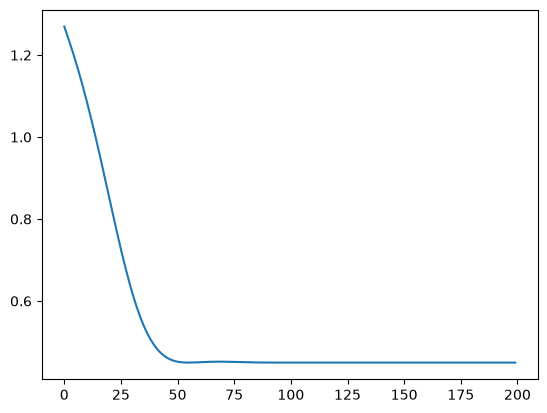

In [6]:
plt.plot(loss_hist1_lt)

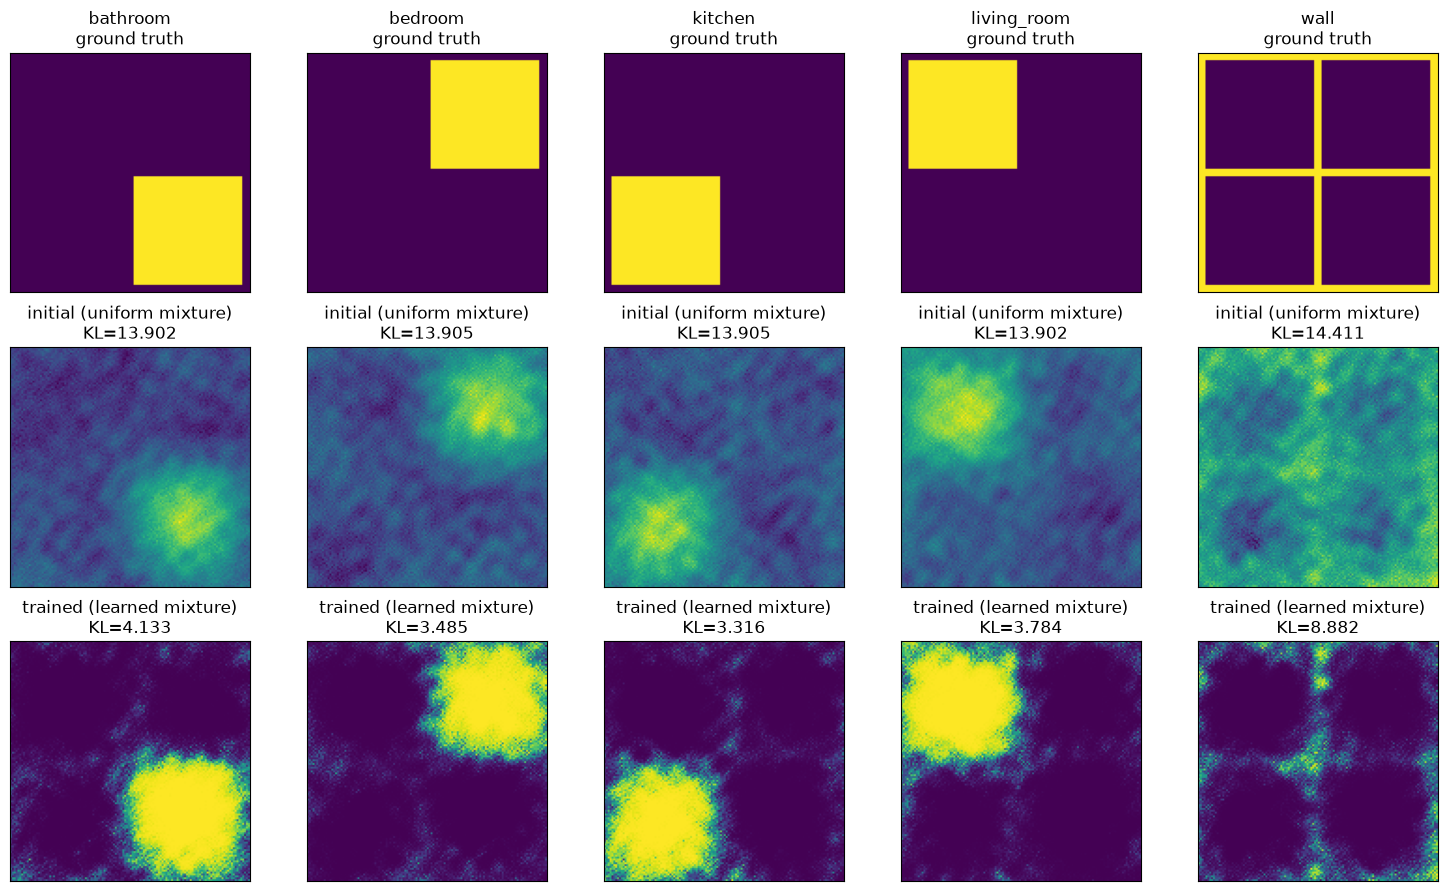

Tier 1 KL, initial (uniform mixture): {np.str_('bathroom'): 13.902, np.str_('bedroom'): 13.905, np.str_('kitchen'): 13.905, np.str_('living_room'): 13.902, np.str_('wall'): 14.411}
Tier 1 KL, trained (learned mixture): {np.str_('bathroom'): 4.133, np.str_('bedroom'): 3.485, np.str_('kitchen'): 3.316, np.str_('living_room'): 3.784, np.str_('wall'): 8.882}


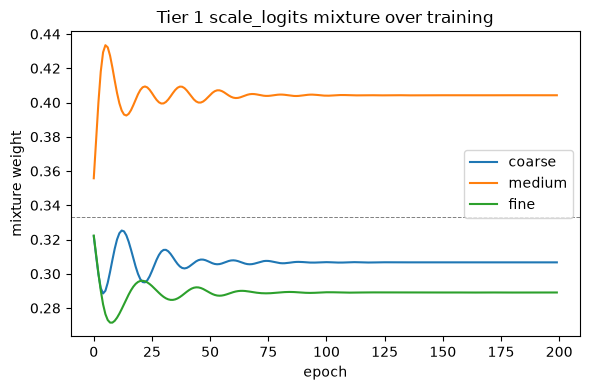

In [7]:
grid_points_t = torch.tensor(xy_all, dtype=torch.float32, device=device)
gt_maps1 = building.room_probability_maps()

# "before training" baseline: same random axis/class/scale encodings, but scale_logits
# still at its init value of 0 (a uniform mixture across coarse/medium/fine), and no
# temperature calibration yet (temperature=1.0).
memory1_init = build_memory_with_scale_logits(
    model1, train_points1, train_labels1, torch.zeros_like(model1.scale_logits.data)
)
est_maps1_init, kl1_init = decode_class_maps(
    model1, memory1_init, grid_points_t, room_to_idx_t1, gt_maps1, H, W, temperature=1.0
)
est_maps1, kl1 = decode_class_maps(
    model1, memory1, grid_points_t, room_to_idx_t1, gt_maps1, H, W, temperature=temp1
)

fig, axes = plt.subplots(3, len(room_names_t1), figsize=(3 * len(room_names_t1), 9))
for col, name in enumerate(room_names_t1):
    axes[0, col].imshow(gt_maps1[name], extent=extent, origin="upper", cmap="viridis")
    axes[0, col].set_title(f"{name}\nground truth")
    axes[1, col].imshow(est_maps1_init[name], extent=extent, origin="upper", cmap="viridis")
    axes[1, col].set_title(f"initial (uniform mixture)\nKL={kl1_init[name]:.3f}")
    axes[2, col].imshow(est_maps1[name], extent=extent, origin="upper", cmap="viridis")
    axes[2, col].set_title(f"trained (learned mixture)\nKL={kl1[name]:.3f}")
    for row in range(3):
        axes[row, col].set_xticks([])
        axes[row, col].set_yticks([])
        axes[row, col].set_aspect("equal")
fig.tight_layout()
plt.show()

print("Tier 1 KL, initial (uniform mixture):", {k: round(v, 3) for k, v in kl1_init.items()})
print("Tier 1 KL, trained (learned mixture):", {k: round(v, 3) for k, v in kl1.items()})

fig, ax = plt.subplots(figsize=(6, 4))
for i, name in enumerate(["coarse", "medium", "fine"]):
    ax.plot(mixture_hist1[:, i], label=name)
ax.axhline(1 / 3, color="gray", linestyle="--", linewidth=0.7)
ax.set_xlabel("epoch")
ax.set_ylabel("mixture weight")
ax.set_title("Tier 1 scale_logits mixture over training")
ax.legend()
fig.tight_layout()
plt.show()

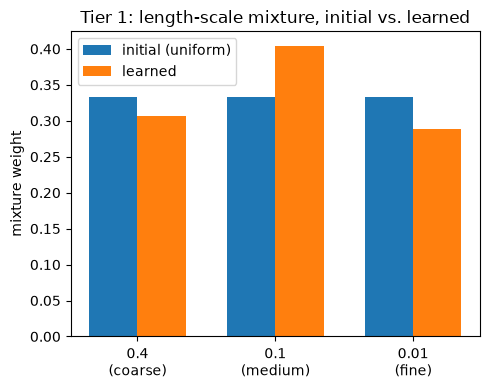

Tier 1 length scales: [0.4, 0.1, 0.01]
  initial (uniform): [0.333 0.333 0.333]
  learned:           [0.307 0.404 0.289]


In [8]:
scale_names = ["coarse", "medium", "fine"]
tier1_scale_labels = [f"{ls:g}" for ls in TIER1_LENGTHSCALES]
mixture1_initial = np.full(len(TIER1_LENGTHSCALES), 1 / len(TIER1_LENGTHSCALES))
mixture1_learned = mixture_hist1[-1]

x = np.arange(len(TIER1_LENGTHSCALES))
width = 0.35
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(x - width / 2, mixture1_initial, width, label="initial (uniform)")
ax.bar(x + width / 2, mixture1_learned, width, label="learned")
ax.set_xticks(x)
ax.set_xticklabels([f"{lbl}\n({name})" for lbl, name in zip(tier1_scale_labels, scale_names)])
ax.set_ylabel("mixture weight")
ax.set_title("Tier 1: length-scale mixture, initial vs. learned")
ax.legend()
fig.tight_layout()
plt.show()

print("Tier 1 length scales:", TIER1_LENGTHSCALES)
print("  initial (uniform):", mixture1_initial.round(3))
print("  learned:          ", mixture1_learned.round(3))

## Tier 2: floor / furniture identity (fine, one memory per room)

One `MultiScaleFHRRMap` per room, 3-way classification: `floor` + that
room's 2 furniture items, trained on *every* point in the room (not just
furniture points).

In [9]:
TIER2_LENGTHSCALES = [0.5, 0.25, 0.1]

tier2 = {}  # room_name -> dict with model, memory, temp, furniture_names, mixture_history, kl, est_maps, gt_maps

furniture_maps_gt = building.furniture_probability_maps()

for room_name in building.room_names:
    room_mask_grid_flat = room_labels_all == room_name  # every point in this room: floor + furniture
    xy_room = xy_all[room_mask_grid_flat]
    furn_room_raw = furniture_labels_all[room_mask_grid_flat]
    furn_room = np.array(["floor" if f is None else f for f in furn_room_raw])

    furn_names_room = sorted(set(furn_room), key=lambda n: (n != "floor", n))  # "floor" first
    furn_to_idx_room = {n: i for i, n in enumerate(furn_names_room)}
    furn_idx_room = np.array([furn_to_idx_room[f] for f in furn_room])

    train_idx2, val_idx2 = make_split(furn_idx_room, num_classes=len(furn_names_room))
    train_points2 = torch.tensor(xy_room[train_idx2], device=device)
    train_labels2 = torch.tensor(furn_idx_room[train_idx2], device=device)
    val_points2 = torch.tensor(xy_room[val_idx2], device=device)
    val_labels2_idx = furn_idx_room[val_idx2]

    class_counts2 = torch.bincount(train_labels2, minlength=len(furn_names_room)).float()
    class_weights2 = class_counts2.sum() / (len(furn_names_room) * class_counts2)
    class_weights2_np = class_weights2.cpu().numpy()

    torch.manual_seed(SEED)
    model2 = MultiScaleFHRRMap(
        dim=DIM, spatial_dim=2, num_classes=len(furn_names_room), lengthscales=TIER2_LENGTHSCALES, device=device,
    )
    memory2, mixture_hist2 = train_model(model2, train_points2, train_labels2, class_weights2, log_mixture=True)
    temp2 = calibrate_temperature(model2, memory2, val_points2, val_labels2_idx, class_weights2_np)

    with torch.no_grad():
        val_probs2 = model2.predict_proba(memory2, val_points2, temperature=temp2).cpu().numpy()
    val_pred2 = val_probs2.argmax(axis=1)
    recall2 = {
        name: float((val_pred2[val_labels2_idx == idx] == idx).mean())
        for name, idx in furn_to_idx_room.items()
    }

    # ground-truth maps for this room: floor (computed here) + its furniture (from BuildingEnv)
    floor_mask_grid = (building.room_grid == room_name) & (building.furniture_grid == "")
    gt_maps_room = {"floor": floor_mask_grid.astype(float) / floor_mask_grid.sum()}
    for name in furn_names_room:
        if name != "floor":
            gt_maps_room[name] = furniture_maps_gt[name]

    room_query_points = torch.tensor(xy_room, dtype=torch.float32, device=device)

    # "before training" baseline, mirroring Tier 1: same encodings, scale_logits still
    # at its init value of 0 (uniform mixture), no temperature calibration yet.
    memory2_init = build_memory_with_scale_logits(
        model2, train_points2, train_labels2, torch.zeros_like(model2.scale_logits.data)
    )
    est_maps2_init, kl2_init = decode_class_maps(
        model2, memory2_init, room_query_points, furn_to_idx_room, gt_maps_room, H, W,
        mask=room_mask_grid_flat, temperature=1.0,
    )
    est_maps2, kl2 = decode_class_maps(
        model2, memory2, room_query_points, furn_to_idx_room, gt_maps_room, H, W,
        mask=room_mask_grid_flat, temperature=temp2,
    )

    tier2[room_name] = dict(
        model=model2, memory=memory2, memory_init=memory2_init, temp=temp2, furniture_names=furn_names_room,
        furniture_to_idx=furn_to_idx_room, mixture_history=mixture_hist2,
        recall=recall2, kl=kl2, est_maps=est_maps2, kl_init=kl2_init, est_maps_init=est_maps2_init,
        gt_maps=gt_maps_room, n_train=len(train_idx2), n_val=len(val_idx2),
    )

    print(f"{room_name:>12s}  classes={furn_names_room}  train={len(train_idx2)} val={len(val_idx2)}  "
          f"temp={temp2:.4g}  mixture={dict(zip(['coarse','medium','fine'], mixture_hist2[-1].round(3)))}")
    print(f"{'':>12s}  recall={ {k: round(v,3) for k,v in recall2.items()} }")
    print(f"{'':>12s}  KL initial={ {k: round(v,3) for k,v in kl2_init.items()} }")
    print(f"{'':>12s}  KL trained={ {k: round(v,3) for k,v in kl2.items()} }")

 living_room  classes=[np.str_('floor'), np.str_('sofa'), np.str_('tv_stand')]  train=2692 val=672  temp=0.007318  mixture={'coarse': np.float32(0.134), 'medium': np.float32(0.323), 'fine': np.float32(0.543)}
              recall={np.str_('floor'): 0.959, np.str_('sofa'): 0.747, np.str_('tv_stand'): 0.0}
              KL initial={np.str_('floor'): 3.125, np.str_('sofa'): 16.82, np.str_('tv_stand'): 18.486}
              KL trained={np.str_('floor'): 1.984, np.str_('sofa'): 12.341, np.str_('tv_stand'): 17.887}


     bedroom  classes=[np.str_('floor'), np.str_('bed'), np.str_('wardrobe')]  train=2692 val=672  temp=0.001867  mixture={'coarse': np.float32(0.192), 'medium': np.float32(0.407), 'fine': np.float32(0.401)}
              recall={np.str_('floor'): 0.95, np.str_('bed'): 0.703, np.str_('wardrobe'): 0.79}
              KL initial={np.str_('floor'): 5.261, np.str_('bed'): 15.458, np.str_('wardrobe'): 17.464}
              KL trained={np.str_('floor'): 2.013, np.str_('bed'): 4.605, np.str_('wardrobe'): 3.6}


     kitchen  classes=[np.str_('floor'), np.str_('stove'), np.str_('table')]  train=2691 val=673  temp=0.002759  mixture={'coarse': np.float32(0.133), 'medium': np.float32(0.356), 'fine': np.float32(0.511)}
              recall={np.str_('floor'): 1.0, np.str_('stove'): 0.862, np.str_('table'): 0.489}
              KL initial={np.str_('floor'): 3.332, np.str_('stove'): 18.532, np.str_('table'): 16.556}
              KL trained={np.str_('floor'): 1.587, np.str_('stove'): 6.738, np.str_('table'): 5.12}


    bathroom  classes=[np.str_('floor'), np.str_('sink'), np.str_('tub')]  train=2691 val=673  temp=0.006021  mixture={'coarse': np.float32(0.203), 'medium': np.float32(0.312), 'fine': np.float32(0.485)}
              recall={np.str_('floor'): 0.969, np.str_('sink'): 0.0, np.str_('tub'): 0.858}
              KL initial={np.str_('floor'): 4.222, np.str_('sink'): 18.373, np.str_('tub'): 15.7}
              KL trained={np.str_('floor'): 2.024, np.str_('sink'): 16.238, np.str_('tub'): 8.021}


### Does the learned-temperature fix change Tier 2's mixture?

Every Tier 2 model already converges to a real, consistent mixture under
plain `train_model` (fine scale landing at 47-53%). Retrain each room's
model tempered too, so the final comparison chart isn't mixing tempered
and untempered results across tiers.

In [10]:
tier2_lt = {}  # room_name -> dict with model, memory, mixture_history, loss_history, recall

for room_name in building.room_names:
    room_mask_grid_flat = room_labels_all == room_name
    xy_room = xy_all[room_mask_grid_flat]
    furn_room_raw = furniture_labels_all[room_mask_grid_flat]
    furn_room = np.array(["floor" if f is None else f for f in furn_room_raw])

    furn_names_room = sorted(set(furn_room), key=lambda n: (n != "floor", n))
    furn_to_idx_room = {n: i for i, n in enumerate(furn_names_room)}
    furn_idx_room = np.array([furn_to_idx_room[f] for f in furn_room])

    train_idx2, val_idx2 = make_split(furn_idx_room, num_classes=len(furn_names_room))
    train_points2 = torch.tensor(xy_room[train_idx2], device=device)
    train_labels2 = torch.tensor(furn_idx_room[train_idx2], device=device)
    val_points2 = torch.tensor(xy_room[val_idx2], device=device)
    val_labels2_idx = furn_idx_room[val_idx2]

    class_counts2 = torch.bincount(train_labels2, minlength=len(furn_names_room)).float()
    class_weights2 = class_counts2.sum() / (len(furn_names_room) * class_counts2)

    torch.manual_seed(SEED)
    model2_lt = MultiScaleFHRRMapLearnedTemp(
        dim=DIM, spatial_dim=2, num_classes=len(furn_names_room), lengthscales=TIER2_LENGTHSCALES, device=device,
    )
    memory2_lt, mixture_hist2_lt, loss_hist2_lt, temp_hist2_lt = train_model_learned_temp(
        model2_lt, train_points2, train_labels2, class_weights2
    )

    with torch.no_grad():
        val_probs2_lt = model2_lt.predict_proba(
            memory2_lt, val_points2, temperature=model2_lt.temperature.item()
        ).cpu().numpy()
    val_pred2_lt = val_probs2_lt.argmax(axis=1)
    recall2_lt = {
        name: float((val_pred2_lt[val_labels2_idx == idx] == idx).mean())
        for name, idx in furn_to_idx_room.items()
    }

    tier2_lt[room_name] = dict(
        model=model2_lt, memory=memory2_lt, mixture_history=mixture_hist2_lt,
        loss_history=loss_hist2_lt, recall=recall2_lt,
    )

    print(f"{room_name:>12s}  learned_temp={model2_lt.temperature.item():.4g}  "
          f"loss(epoch0->199)={loss_hist2_lt[0]:.4f}->{loss_hist2_lt[-1]:.4f}  "
          f"mixture={dict(zip(['coarse','medium','fine'], mixture_hist2_lt[-1].round(3)))}")
    print(f"{'':>12s}  recall={ {k: round(v,3) for k,v in recall2_lt.items()} }")

 living_room  learned_temp=0.0006523  loss(epoch0->199)=0.9977->0.1824  mixture={'coarse': np.float32(0.001), 'medium': np.float32(0.147), 'fine': np.float32(0.852)}
              recall={np.str_('floor'): 0.971, np.str_('sofa'): 0.831, np.str_('tv_stand'): 1.0}


     bedroom  learned_temp=0.001068  loss(epoch0->199)=0.7396->0.1500  mixture={'coarse': np.float32(0.004), 'medium': np.float32(0.393), 'fine': np.float32(0.603)}
              recall={np.str_('floor'): 0.938, np.str_('bed'): 0.898, np.str_('wardrobe'): 0.984}


     kitchen  learned_temp=0.0006695  loss(epoch0->199)=0.8217->0.1206  mixture={'coarse': np.float32(0.002), 'medium': np.float32(0.093), 'fine': np.float32(0.906)}
              recall={np.str_('floor'): 0.975, np.str_('stove'): 1.0, np.str_('table'): 0.913}


    bathroom  learned_temp=0.0007052  loss(epoch0->199)=0.7581->0.1779  mixture={'coarse': np.float32(0.001), 'medium': np.float32(0.081), 'fine': np.float32(0.918)}
              recall={np.str_('floor'): 0.96, np.str_('sink'): 0.912, np.str_('tub'): 0.917}


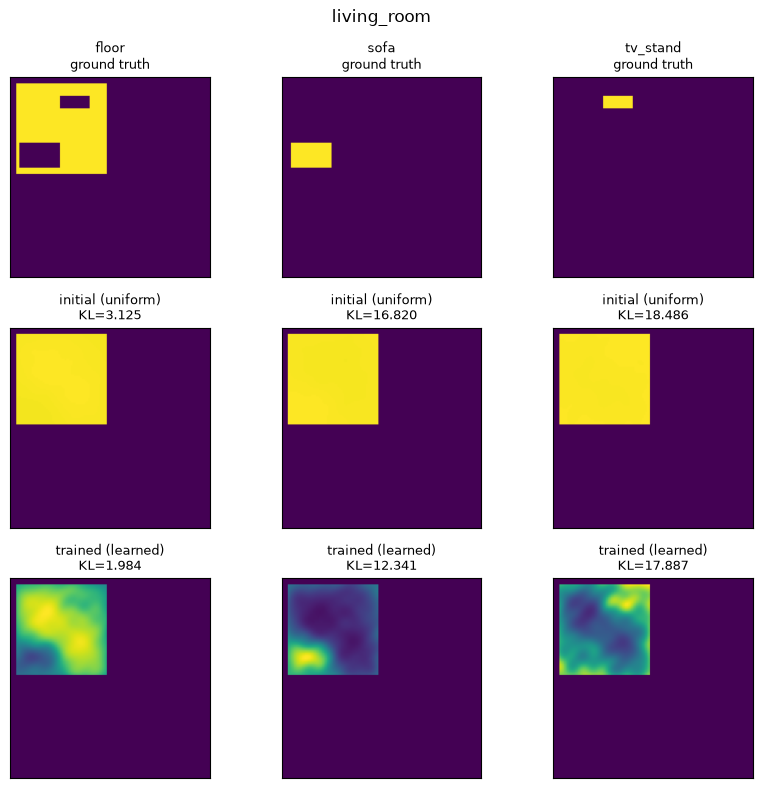

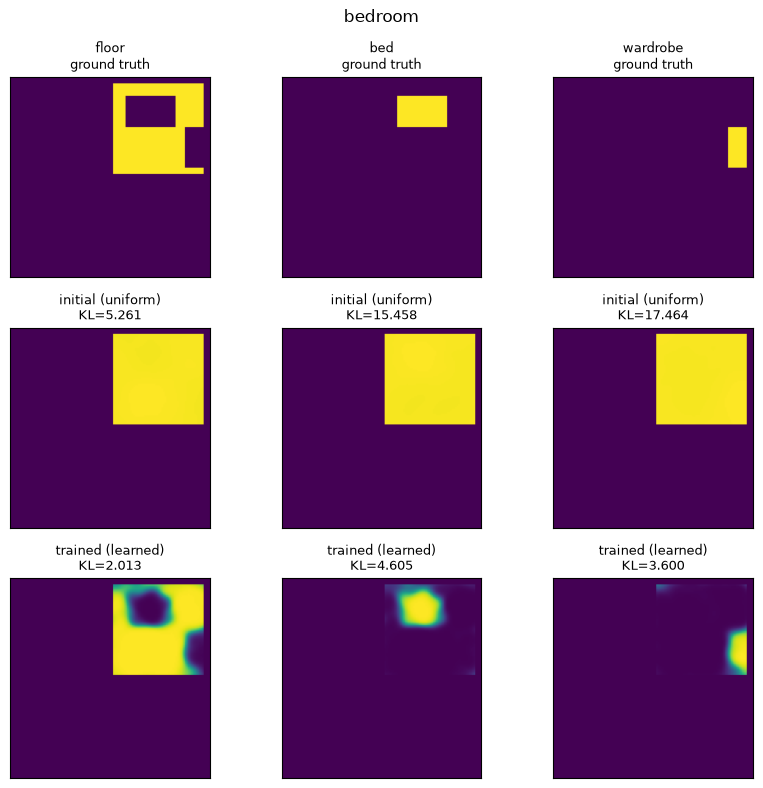

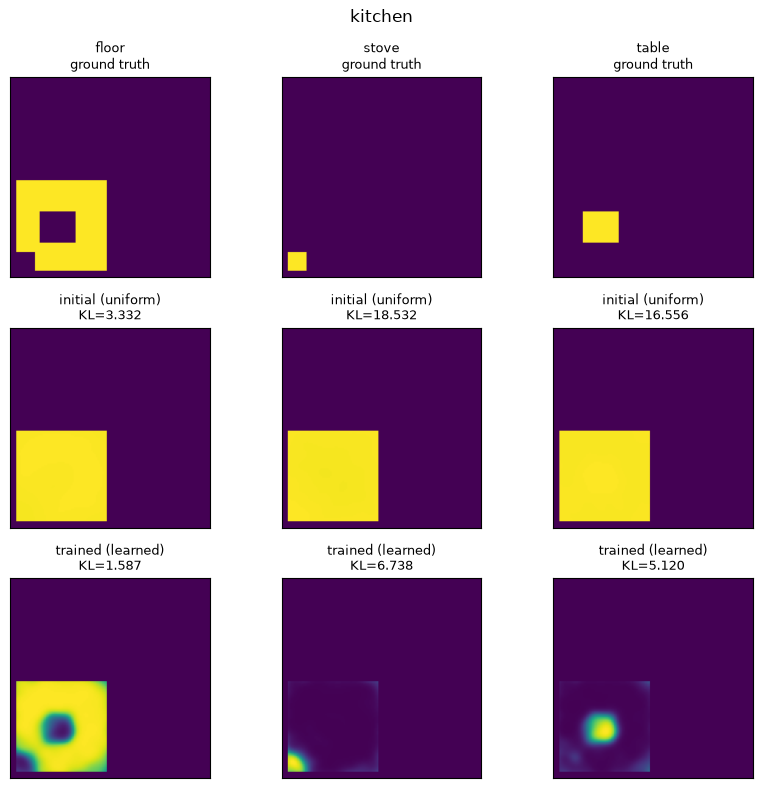

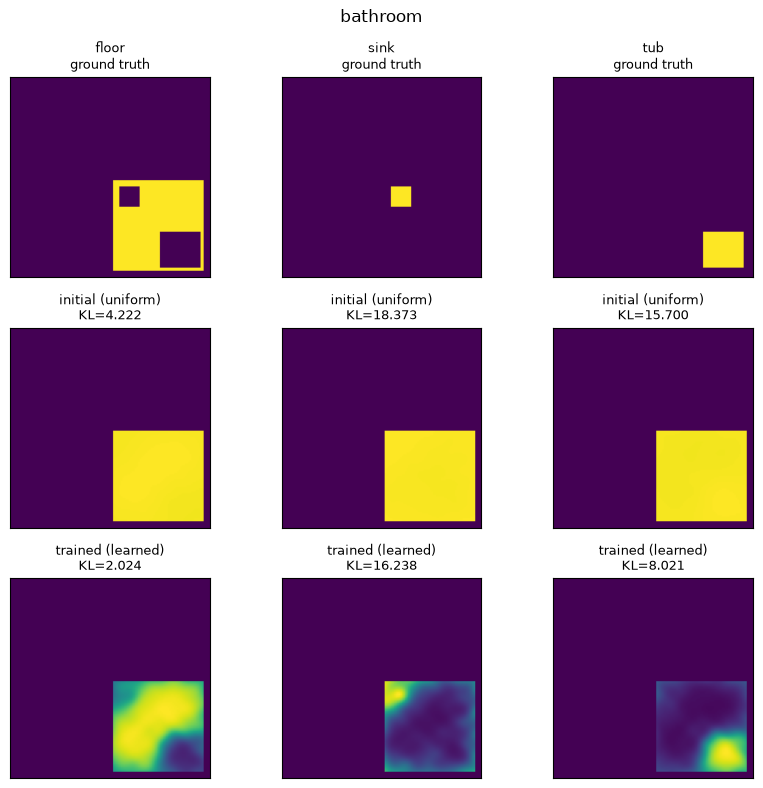

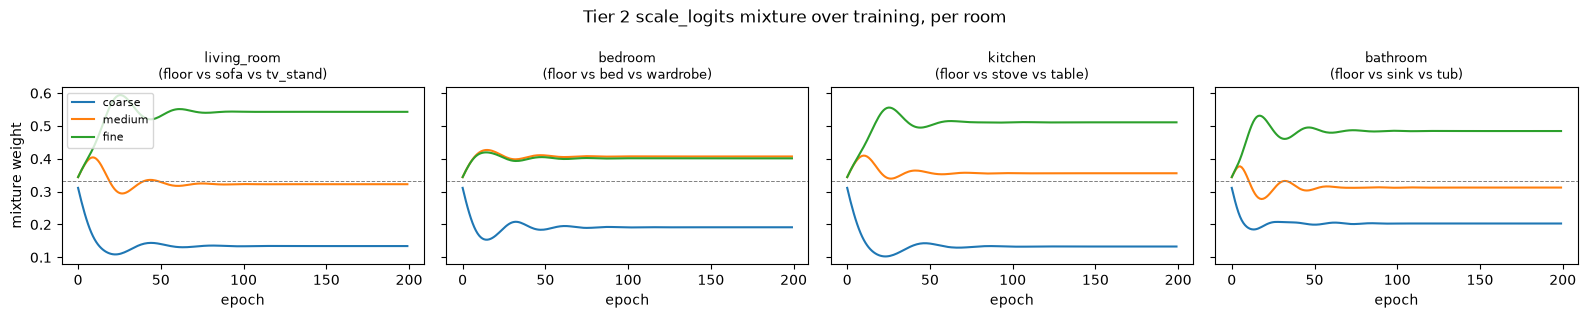

In [11]:
for room_name in building.room_names:
    d = tier2[room_name]
    names = d["furniture_names"]  # "floor" first, then that room's furniture
    fig, axes = plt.subplots(3, len(names), figsize=(2.8 * len(names), 8))
    for col, name in enumerate(names):
        axes[0, col].imshow(d["gt_maps"][name], extent=extent, origin="upper", cmap="viridis")
        axes[0, col].set_title(f"{name}\nground truth", fontsize=9)
        axes[1, col].imshow(d["est_maps_init"][name], extent=extent, origin="upper", cmap="viridis")
        axes[1, col].set_title(f"initial (uniform)\nKL={d['kl_init'][name]:.3f}", fontsize=9)
        axes[2, col].imshow(d["est_maps"][name], extent=extent, origin="upper", cmap="viridis")
        axes[2, col].set_title(f"trained (learned)\nKL={d['kl'][name]:.3f}", fontsize=9)
        for row in range(3):
            axes[row, col].set_xticks([])
            axes[row, col].set_yticks([])
            axes[row, col].set_aspect("equal")
    fig.suptitle(room_name)
    fig.tight_layout()
    plt.show()

fig, axes = plt.subplots(1, len(building.room_names), figsize=(4 * len(building.room_names), 3.2), sharey=True)
for ax, room_name in zip(axes, building.room_names):
    hist = tier2[room_name]["mixture_history"]
    for i, name in enumerate(["coarse", "medium", "fine"]):
        ax.plot(hist[:, i], label=name)
    ax.axhline(1 / 3, color="gray", linestyle="--", linewidth=0.7)
    ax.set_title(f"{room_name}\n({' vs '.join(tier2[room_name]['furniture_names'])})", fontsize=9)
    ax.set_xlabel("epoch")
axes[0].set_ylabel("mixture weight")
axes[0].legend(fontsize=8)
fig.suptitle("Tier 2 scale_logits mixture over training, per room")
fig.tight_layout()
plt.show()

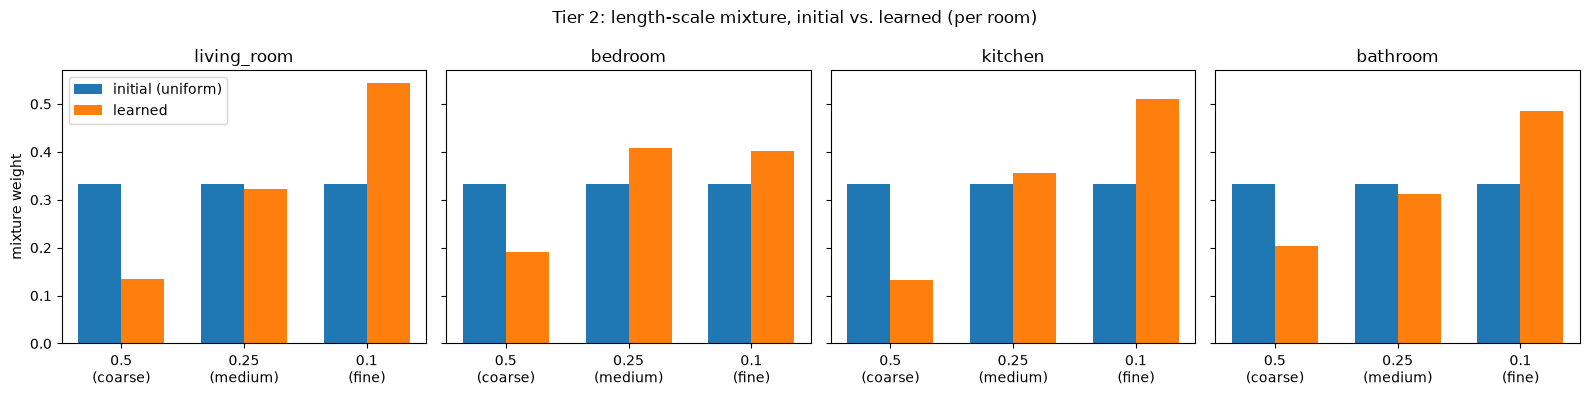

Tier 2 length scales: [0.5, 0.25, 0.1]
  initial (uniform): [0.333 0.333 0.333]
   living_room learned: [0.134 0.323 0.543]
       bedroom learned: [0.192 0.407 0.401]
       kitchen learned: [0.133 0.356 0.511]
      bathroom learned: [0.203 0.312 0.485]


In [12]:
tier2_scale_labels = [f"{ls:g}" for ls in TIER2_LENGTHSCALES]
mixture2_initial = np.full(len(TIER2_LENGTHSCALES), 1 / len(TIER2_LENGTHSCALES))

x = np.arange(len(TIER2_LENGTHSCALES))
width = 0.35
fig, axes = plt.subplots(1, len(building.room_names), figsize=(4 * len(building.room_names), 4), sharey=True)
for ax, room_name in zip(axes, building.room_names):
    mixture2_learned = tier2[room_name]["mixture_history"][-1]
    ax.bar(x - width / 2, mixture2_initial, width, label="initial (uniform)")
    ax.bar(x + width / 2, mixture2_learned, width, label="learned")
    ax.set_xticks(x)
    ax.set_xticklabels([f"{lbl}\n({name})" for lbl, name in zip(tier2_scale_labels, scale_names)])
    ax.set_title(room_name)
axes[0].set_ylabel("mixture weight")
axes[0].legend()
fig.suptitle("Tier 2: length-scale mixture, initial vs. learned (per room)")
fig.tight_layout()
plt.show()

print("Tier 2 length scales:", TIER2_LENGTHSCALES)
print("  initial (uniform):", mixture2_initial.round(3))
for room_name in building.room_names:
    print(f"  {room_name:>12s} learned:", tier2[room_name]["mixture_history"][-1].round(3))